# Кейс 5 — Антифрод анализ: выявление некачественного трафика

**Контекст:** Media buying / iGaming аналитика  
**Период данных:** Q1–Q2 2024  
**Инструменты:** Python (pandas, matplotlib)  
**Датасет:** `fraud_signals.csv` + `players.csv`

---

## Постановка задачи

Фрод — одна из главных проблем в медиабаинге.  
Мошеннический трафик выглядит как реальные конверсии, но игроки не вносят депозиты  
и не приносят доход. Результат: ты платишь за CPA, которое ничего не стоит.

**Типы фрода в нашем датасете:**

| Тип | Паттерн | Что происходит |
|---|---|---|
| `HIGH_FRAUD_RATE` | fraud_rate > 10% | Подозрительные клики, боты или фермы кликов |
| `CTR_SPIKE+LOW_QUALITY` | CTR > 20%, r2d < 1% | Масса кликов, ни один не конвертируется в депозит |
| `CLICK_INJECTION_PATTERN` | Высокий CTR, c2r < 2% | Клики инжектируются в момент установки/открытия |

**Вопросы для анализа:**
1. Какой источник имеет наибольший процент аномалий?
2. Как выглядят паттерны фрода — чем аномальные строки отличаются от нормальных?
3. Можно ли автоматически выявлять фрод правилами?
4. Что делать с каждым источником?

---


## 0. Импорт и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#F8F9FA'})

COLORS = {
    'Google_Search': '#4285F4', 'Facebook':      '#1877F2',
    'Native_Ads':    '#FF9500', 'Push_Network':  '#E53935',
    'TikTok':        '#69C9D0', 'Affiliate_SEO': '#34A853',
}
ALERT_COLORS = {
    'NORMAL':                  '#A5D6A7',
    'HIGH_FRAUD_RATE':         '#FFCC80',
    'CTR_SPIKE+LOW_QUALITY':   '#EF9A9A',
    'CLICK_INJECTION_PATTERN': '#CE93D8',
}
SRC_ORDER = ['Google_Search', 'Facebook', 'Affiliate_SEO', 'Native_Ads', 'TikTok', 'Push_Network']


In [2]:
fraud = pd.read_csv('../data/fraud_signals.csv')

print(f"fraud_signals: {fraud.shape}")
print(f"Поля: {list(fraud.columns)}")
print(f"\nТипы аномалий:")
print(fraud['alert_type'].value_counts())
print(f"\nАномальных строк: {fraud['is_anomaly'].sum():,} ({fraud['is_anomaly'].mean():.1%})")


fraud_signals: (7654, 13)
Поля: ['date', 'source', 'geo', 'clicks', 'registrations', 'ftd', 'ctr', 'c2r', 'fraud_rate', 'approval_rate', 'r2d', 'alert_type', 'is_anomaly']

Типы аномалий:
NORMAL                     6362
HIGH_FRAUD_RATE            1282
CTR_SPIKE+LOW_QUALITY         8
CLICK_INJECTION_PATTERN       2
Name: alert_type, dtype: int64

Аномальных строк: 1,292 (16.9%)


## 1. Подготовка данных и расчёт метрик

In [3]:
# Переводим доли в проценты для удобства анализа
fraud['ctr_pct']        = (fraud['ctr']          * 100).round(3)
fraud['c2r_pct']        = (fraud['c2r']          * 100).round(3)
fraud['r2d_pct']        = (fraud['r2d']          * 100).round(3)
fraud['fraud_rate_pct'] = (fraud['fraud_rate']   * 100).round(3)
fraud['reject_rate_pct']= ((1 - fraud['approval_rate']) * 100).round(3)
fraud['month']          = fraud['date'].str[:7]

# Сводная статистика по источникам
src_stats = fraud.groupby('source').agg(
    total_rows     = ('is_anomaly',      'count'),
    anomalies      = ('is_anomaly',      'sum'),
    avg_ctr_pct    = ('ctr_pct',         'mean'),
    avg_c2r_pct    = ('c2r_pct',         'mean'),
    avg_r2d_pct    = ('r2d_pct',         'mean'),
    avg_fraud_pct  = ('fraud_rate_pct',  'mean'),
    avg_approval   = ('approval_rate',   'mean'),
    avg_reject_pct = ('reject_rate_pct', 'mean'),
).round(2).reset_index()
src_stats['anomaly_pct'] = (src_stats['anomalies'] / src_stats['total_rows'] * 100).round(1)

print("=== Сводная таблица по источникам ===")
src_stats[['source','total_rows','anomalies','anomaly_pct',
           'avg_fraud_pct','avg_reject_pct','avg_r2d_pct','avg_approval']]    .sort_values('anomaly_pct', ascending=False)    .style.background_gradient(subset=['anomaly_pct','avg_fraud_pct'], cmap='RdYlGn_r')    .format({'anomaly_pct':'{:.1f}%','avg_fraud_pct':'{:.2f}%',
             'avg_reject_pct':'{:.2f}%','avg_approval':'{:.3f}'})


=== Сводная таблица по источникам ===


,source,total_rows,anomalies,anomaly_pct,avg_fraud_pct,avg_reject_pct,avg_r2d_pct,avg_approval
4,Push_Network,1282,983,76.7%,13.96%,14.18%,8.380000,0.860
5,TikTok,1276,309,24.2%,7.97%,8.07%,13.660000,0.920
0,Affiliate_SEO,1274,0,0.0%,1.57%,1.99%,32.730000,0.980
1,Facebook,1274,0,0.0%,2.93%,2.98%,22.960000,0.970
2,Google_Search,1274,0,0.0%,0.93%,1.00%,29.550000,0.990
3,Native_Ads,1274,0,0.0%,5.88%,5.98%,17.950000,0.940


## 2. Правила детекции фрода (Rule-Based)

Самый практичный подход для junior analyst — написать набор правил на основе аномальных значений метрик.  
Каждое правило проверяет одно условие. Если сработало одно или более — строка помечается как фрод.


In [4]:
# Правила детекции
fraud['rule_ctr_spike']    = (fraud['ctr_pct']        > 12).astype(int)  # CTR > 12%
fraud['rule_high_fraud']   = (fraud['fraud_rate_pct'] > 10).astype(int)  # Fraud rate > 10%
fraud['rule_low_approval'] = (fraud['approval_rate']  < 0.75).astype(int)# Approval < 75%
fraud['rule_c2r_r2d_gap']  = ((fraud['c2r_pct'] > 15) &
                               (fraud['r2d_pct'] < 2)).astype(int)        # Много рег., ноль депозитов
fraud['rule_low_r2d']      = (fraud['r2d_pct'] < 2).astype(int)          # r2d < 2%

# Сумма сработавших правил
fraud['rules_triggered'] = (fraud[['rule_ctr_spike','rule_high_fraud',
                                    'rule_low_approval','rule_c2r_r2d_gap',
                                    'rule_low_r2d']].sum(axis=1))
fraud['detected_fraud']  = (fraud['rules_triggered'] >= 1).astype(int)

# Качество детекции
tp = ((fraud['detected_fraud']==1) & (fraud['is_anomaly']==1)).sum()
fp = ((fraud['detected_fraud']==1) & (fraud['is_anomaly']==0)).sum()
fn = ((fraud['detected_fraud']==0) & (fraud['is_anomaly']==1)).sum()
tn = ((fraud['detected_fraud']==0) & (fraud['is_anomaly']==0)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("=== Качество системы детекции ===")
print(f"  True Positives  (поймали фрод):       {tp:,}")
print(f"  False Positives (ошибочно помечены):  {fp:,}")
print(f"  False Negatives (пропустили фрод):    {fn:,}")
print(f"  True Negatives  (верно чистые):       {tn:,}")
print(f"\n  Precision: {precision:.3f}  (из помеченных как фрод — {precision:.1%} реально фрод)")
print(f"  Recall:    {recall:.3f}  (из реального фрода — {recall:.1%} поймали)")
print(f"  F1-Score:  {f1:.3f}")


=== Качество системы детекции ===
  True Positives  (поймали фрод):       1,292
  False Positives (ошибочно помечены):  92
  False Negatives (пропустили фрод):    0
  True Negatives  (верно чистые):       6,270

  Precision: 0.934  (из помеченных как фрод — 93.4% реально фрод)
  Recall:    1.000  (из реального фрода — 100.0% поймали)
  F1-Score:  0.966


## 3. Паттерны аномалий

In [5]:
# Сравнение метрик: нормальные vs аномальные строки
compare = fraud.groupby('is_anomaly').agg(
    count         = ('is_anomaly',      'count'),
    avg_ctr       = ('ctr_pct',         'mean'),
    avg_c2r       = ('c2r_pct',         'mean'),
    avg_r2d       = ('r2d_pct',         'mean'),
    avg_fraud_rate= ('fraud_rate_pct',  'mean'),
    avg_approval  = ('approval_rate',   'mean'),
).round(3)
compare.index = ['Норма (is_anomaly=0)', 'Аномалия (is_anomaly=1)']

print("=== Сравнение: нормальный vs аномальный трафик ===")
compare.T


=== Сравнение: нормальный vs аномальный трафик ===


,Норма (is_anomaly=0),Аномалия (is_anomaly=1)
count,6362.000,1292.000
avg_ctr,2.595,2.163
avg_c2r,11.559,4.449
avg_r2d,23.145,9.579
avg_fraud_rate,3.724,14.535
avg_approval,0.957,0.872


In [6]:
# Детальный разбор инжектированных аномалий (вброшенные сценарии)
severe = fraud[fraud['alert_type'].isin(['CTR_SPIKE+LOW_QUALITY', 'CLICK_INJECTION_PATTERN'])]
print("=== Критические аномалии (CTR-спайк и Click Injection) ===")
print(severe[['date','source','geo','clicks','ctr_pct','c2r_pct',
              'r2d_pct','fraud_rate_pct','approval_rate','alert_type']]      .sort_values('date').to_string(index=False))
print("\nПаттерн CTR_SPIKE: CTR 20-28%, регистрации есть, но r2d < 1% — никто не депозитит.")
print("Паттерн CLICK_INJECTION: CTR 18%, c2r 1-2% — клики не конвертируются в регистрации.")


=== Критические аномалии (CTR-спайк и Click Injection) ===
      date       source geo  clicks  ctr_pct  c2r_pct  r2d_pct  fraud_rate_pct  approval_rate              alert_type
2024-02-14 Push_Network  IN    9207    27.70    27.49     0.33           28.64          0.487   CTR_SPIKE+LOW_QUALITY
2024-02-14 Push_Network  NG    7621    23.99    17.34     0.29           26.16          0.623   CTR_SPIKE+LOW_QUALITY
2024-03-08 Push_Network  IN    8192    23.14    23.89     0.23           37.15          0.484   CTR_SPIKE+LOW_QUALITY
2024-03-08 Push_Network  NG    7129    20.91    24.18     0.28           30.84          0.523   CTR_SPIKE+LOW_QUALITY
2024-03-22       TikTok  BR    9966    18.42     1.11     1.19           31.58          0.580 CLICK_INJECTION_PATTERN
2024-04-21 Push_Network  IN    5854    27.09    18.88     0.60           31.23          0.554   CTR_SPIKE+LOW_QUALITY
2024-04-21 Push_Network  NG    5455    26.08    19.57     0.26           38.68          0.538   CTR_SPIKE+LOW_QUALI

## 4. Визуализация

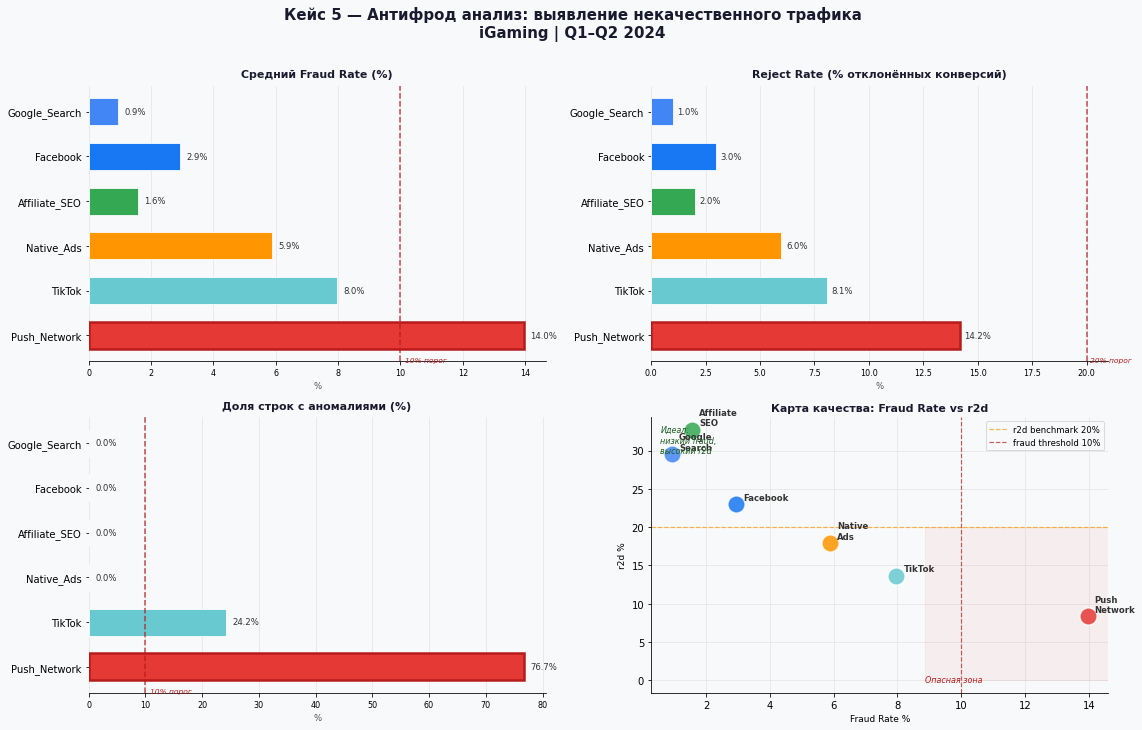

In [7]:
# ── Figure 1: Обзор fraud-метрик по источникам ───────────────────────────────
src_s = src_stats.set_index('source').reindex(SRC_ORDER).reset_index()
src_s['reject_rate'] = src_s['avg_reject_pct']

palette = [COLORS[s] for s in SRC_ORDER]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Кейс 5 — Антифрод анализ: выявление некачественного трафика\niGaming | Q1–Q2 2024',
             fontsize=15, fontweight='bold', color='#1A1A2E', y=1.01)

def hbar(ax, vals, labels, colors, title, xlabel, fmt='{}', thr=None, thr_lbl=''):
    bars = ax.barh(labels, vals, color=colors, edgecolor='white', lw=0.8, height=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8, color='#1A1A2E')
    ax.set_xlabel(xlabel, fontsize=8.5, color='#555'); ax.invert_yaxis()
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.set_facecolor('#F8F9FA'); ax.xaxis.grid(True,color='#E0E0E0',lw=0.6); ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=10); ax.tick_params(axis='x', labelsize=8)
    vmax = max(vals) if max(vals) > 0 else 1
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width()+vmax*0.015, bar.get_y()+bar.get_height()/2,
                fmt.format(val), va='center', ha='left', fontsize=8.5, color='#333')
    if thr:
        ax.axvline(thr, color='#B71C1C', lw=1.5, ls='--', alpha=0.8)
        ax.text(thr + vmax*0.01, len(labels)-0.4, thr_lbl, fontsize=7.5,
                color='#B71C1C', style='italic')
    valid = [(i,v) for i,v in enumerate(vals) if v > 0]
    if valid:
        bi = max(valid, key=lambda x: x[1])[0]
        bars[bi].set_edgecolor('#B71C1C'); bars[bi].set_linewidth(2.5)

hbar(axes[0,0], src_s['avg_fraud_pct'].tolist(), SRC_ORDER, palette,
     'Средний Fraud Rate (%)', '%', fmt='{:.1f}%', thr=10, thr_lbl='10% порог')

hbar(axes[0,1], src_s['reject_rate'].tolist(), SRC_ORDER, palette,
     'Reject Rate (% отклонённых конверсий)', '%', fmt='{:.1f}%', thr=20, thr_lbl='20% порог')

hbar(axes[1,0], src_s['anomaly_pct'].tolist(), SRC_ORDER, palette,
     'Доля строк с аномалиями (%)', '%', fmt='{:.1f}%', thr=10, thr_lbl='10% порог')

# Scatter quality map
ax4 = axes[1,1]
for _, row in src_s.iterrows():
    src = row['source']
    ax4.scatter(row['avg_fraud_pct'], row['avg_r2d_pct'],
                s=300, color=COLORS[src], alpha=0.85, edgecolors='white', lw=1.5, zorder=3)
    ax4.annotate(src.replace('_','\n'), (row['avg_fraud_pct'], row['avg_r2d_pct']),
                 textcoords='offset points', xytext=(7,4), fontsize=8.5,
                 color='#333', fontweight='bold')
ax4.axhline(20, color='#FF9800', lw=1.2, ls='--', alpha=0.7, label='r2d benchmark 20%')
ax4.axvline(10, color='#B71C1C', lw=1.2, ls='--', alpha=0.7, label='fraud threshold 10%')
ax4.axhspan(0, 20, xmin=0.6, alpha=0.06, color='#E53935')
ax4.set_title('Карта качества: Fraud Rate vs r2d', fontsize=11, fontweight='bold', color='#1A1A2E')
ax4.set_xlabel('Fraud Rate %', fontsize=9); ax4.set_ylabel('r2d %', fontsize=9)
ax4.text(0.02,0.97,'Идеал:\nнизкий fraud,\nвысокий r2d',
         transform=ax4.transAxes, fontsize=8, va='top', color='#1B5E20', style='italic')
ax4.text(0.6,0.03,'Опасная зона',
         transform=ax4.transAxes, fontsize=8, va='bottom', color='#B71C1C', style='italic')
for sp in ['top','right']: ax4.spines[sp].set_visible(False)
ax4.set_facecolor('#F8F9FA'); ax4.grid(color='#E0E0E0',lw=0.6); ax4.set_axisbelow(True)
ax4.legend(fontsize=8.5, framealpha=0.7)

plt.tight_layout()
plt.show()


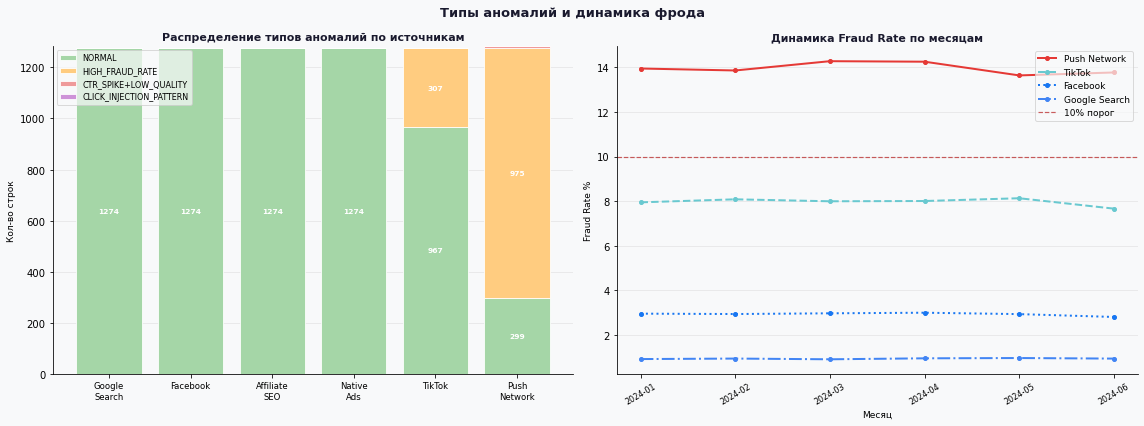

In [8]:
# ── Figure 2: Распределение типов аномалий + динамика fraud rate ─────────────
fig2, axes = plt.subplots(1, 2, figsize=(16, 6))
fig2.patch.set_facecolor('#F8F9FA')

# Left: stacked bar — alert types by source
ax = axes[0]
alert_types  = ['NORMAL','HIGH_FRAUD_RATE','CTR_SPIKE+LOW_QUALITY','CLICK_INJECTION_PATTERN']
alert_pivot  = fraud.groupby(['source','alert_type']).size().unstack(fill_value=0)
alert_pivot  = alert_pivot.reindex(
    index=[s for s in SRC_ORDER if s in alert_pivot.index],
    columns=[a for a in alert_types if a in alert_pivot.columns],
    fill_value=0
)
bottom = np.zeros(len(alert_pivot))
for atype in alert_pivot.columns:
    vals = alert_pivot[atype].values
    bars = ax.bar(alert_pivot.index, vals, bottom=bottom,
                  label=atype, color=ALERT_COLORS.get(atype,'#90A4AE'),
                  edgecolor='white', lw=0.8)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 50:
            ax.text(bar.get_x()+bar.get_width()/2, bot+val/2, str(int(val)),
                    ha='center', va='center', fontsize=7.5,
                    color='white', fontweight='bold')
    bottom += vals

ax.set_title('Распределение типов аномалий по источникам', fontsize=11,
              fontweight='bold', color='#1A1A2E')
ax.set_xticklabels([s.replace('_','\n') for s in alert_pivot.index], fontsize=8.5)
ax.set_ylabel('Кол-во строк', fontsize=9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=8, framealpha=0.7, loc='upper left')

# Right: fraud rate time series
ax2 = axes[1]
for src, ls in [('Push_Network','-'),('TikTok','--'),('Facebook',':'),('Google_Search','-.')]:
    sub = fraud[fraud['source']==src].groupby('month')['fraud_rate_pct'].mean().reset_index()
    ax2.plot(sub['month'], sub['fraud_rate_pct'], marker='o', markersize=4,
             lw=2, ls=ls, color=COLORS[src], label=src.replace('_',' '))
ax2.axhline(10, color='#B71C1C', lw=1.2, ls='--', alpha=0.7, label='10% порог')
ax2.set_title('Динамика Fraud Rate по месяцам', fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('Месяц', fontsize=9); ax2.set_ylabel('Fraud Rate %', fontsize=9)
ax2.tick_params(axis='x', rotation=30, labelsize=8)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=9, framealpha=0.7)

fig2.suptitle('Типы аномалий и динамика фрода', fontsize=13,
               fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


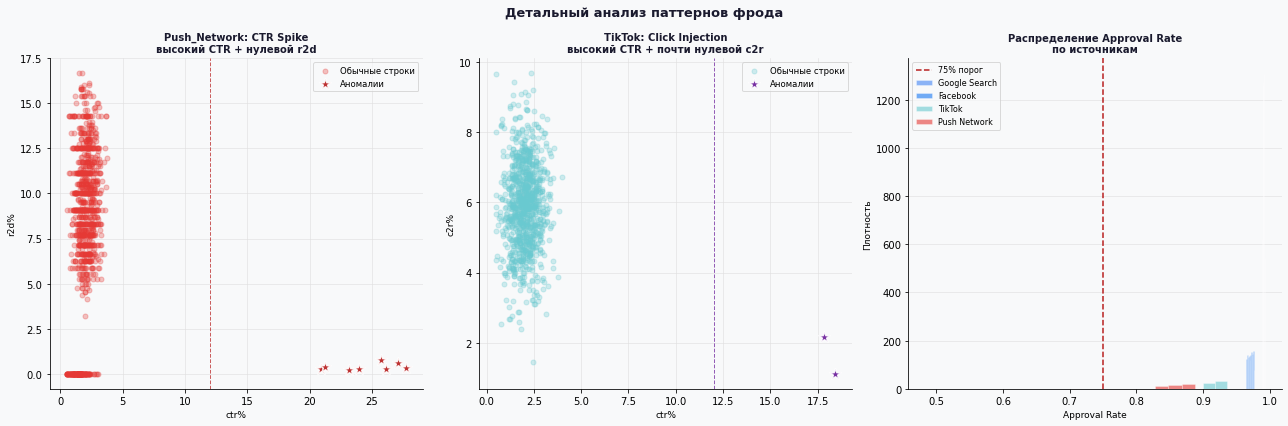

In [9]:
# ── Figure 3: Детальный анализ паттернов фрода ───────────────────────────────
anom        = fraud[fraud['alert_type'].isin(['CTR_SPIKE+LOW_QUALITY','CLICK_INJECTION_PATTERN'])]
normal_push = fraud[(fraud['source']=='Push_Network') & (fraud['alert_type']=='HIGH_FRAUD_RATE')]
normal_tik  = fraud[(fraud['source']=='TikTok')       & (fraud['alert_type']=='NORMAL')]

fig3, axes = plt.subplots(1, 3, figsize=(18, 6))
fig3.patch.set_facecolor('#F8F9FA')

def scatter_compare(ax, normal_df, anom_df, xcol, ycol, title, src_color, anom_color):
    ax.scatter(normal_df[xcol], normal_df[ycol], s=25, color=src_color,
               alpha=0.3, label='Обычные строки', zorder=2)
    ax.scatter(anom_df[xcol], anom_df[ycol], s=140, color=anom_color,
               alpha=0.9, edgecolors='white', lw=1.5, label='Аномалии', zorder=3, marker='*')
    ax.set_title(title, fontsize=10, fontweight='bold', color='#1A1A2E')
    ax.set_xlabel(xcol.replace('_pct','%').replace('_',' '), fontsize=9)
    ax.set_ylabel(ycol.replace('_pct','%').replace('_',' '), fontsize=9)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.set_facecolor('#F8F9FA'); ax.grid(color='#E0E0E0',lw=0.6); ax.set_axisbelow(True)
    ax.legend(fontsize=8.5, framealpha=0.7)

# Push: CTR Spike
push_anom = anom[anom['source']=='Push_Network']
scatter_compare(axes[0], normal_push, push_anom, 'ctr_pct', 'r2d_pct',
                'Push_Network: CTR Spike\nвысокий CTR + нулевой r2d',
                COLORS['Push_Network'], '#B71C1C')
axes[0].axvline(12, color='#B71C1C', lw=1, ls='--', alpha=0.7)

# TikTok: Click Injection
tik_anom = anom[anom['source']=='TikTok']
scatter_compare(axes[1], normal_tik, tik_anom, 'ctr_pct', 'c2r_pct',
                'TikTok: Click Injection\nвысокий CTR + почти нулевой c2r',
                COLORS['TikTok'], '#6A1B9A')
axes[1].axvline(12, color='#6A1B9A', lw=1, ls='--', alpha=0.7)

# Approval rate distribution
ax3 = axes[2]
for src in ['Google_Search','Facebook','TikTok','Push_Network']:
    sub = fraud[fraud['source']==src]['approval_rate']
    ax3.hist(sub, bins=20, alpha=0.6, color=COLORS[src],
             label=src.replace('_',' '), density=True, edgecolor='white', lw=0.5)
ax3.axvline(0.75, color='#B71C1C', lw=1.5, ls='--', label='75% порог')
ax3.set_title('Распределение Approval Rate\nпо источникам', fontsize=10,
               fontweight='bold', color='#1A1A2E')
ax3.set_xlabel('Approval Rate', fontsize=9); ax3.set_ylabel('Плотность', fontsize=9)
for sp in ['top','right']: ax3.spines[sp].set_visible(False)
ax3.set_facecolor('#F8F9FA'); ax3.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax3.set_axisbelow(True)
ax3.legend(fontsize=8, framealpha=0.7)

fig3.suptitle('Детальный анализ паттернов фрода', fontsize=13,
               fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


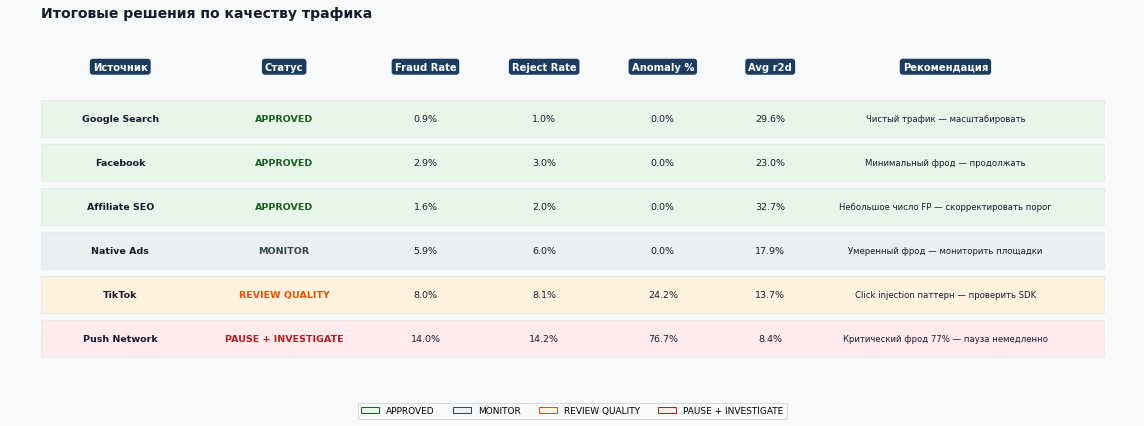

In [10]:
# ── Figure 4: Итоговая таблица решений ───────────────────────────────────────
fig4, ax = plt.subplots(figsize=(16, 6))
fig4.patch.set_facecolor('#F8F9FA')
ax.axis('off')

def src_decision(row):
    if row['avg_fraud_pct'] > 12 or row['reject_rate'] > 15 or row['anomaly_pct'] > 60:
        return 'PAUSE + INVESTIGATE', '#B71C1C', '#FFEBEE'
    if row['avg_fraud_pct'] > 8 or row['reject_rate'] > 10 or row['anomaly_pct'] > 20:
        return 'REVIEW QUALITY',      '#E65100', '#FFF3E0'
    if row['avg_fraud_pct'] < 3 and row['reject_rate'] < 5:
        return 'APPROVED',            '#1B5E20', '#E8F5E9'
    return 'MONITOR',                 '#37474F', '#ECEFF1'

recommendations = {
    'Google_Search': 'Чистый трафик — масштабировать',
    'Facebook':      'Минимальный фрод — продолжать',
    'Affiliate_SEO': 'Небольшое число FP — скорректировать порог',
    'Native_Ads':    'Умеренный фрод — мониторить площадки',
    'TikTok':        'Click injection паттерн — проверить SDK',
    'Push_Network':  'Критический фрод 77% — пауза немедленно',
}

col_headers = ['Источник','Статус','Fraud Rate','Reject Rate','Anomaly %',
               'Avg r2d','Рекомендация']
col_widths  = [0.14, 0.15, 0.10, 0.11, 0.10, 0.09, 0.22]

x = 0.03
for h, w in zip(col_headers, col_widths):
    ax.text(x+w/2, 0.92, h, ha='center', va='center', fontsize=10, fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A3C5E', edgecolor='none'))
    x += w

for i, src in enumerate(SRC_ORDER):
    row = src_s[src_s['source']==src].iloc[0]
    dec, tc, bc = src_decision(row)
    y = 0.78 - i*0.12
    ax.add_patch(plt.Rectangle((0.03, y-0.05), 0.94, 0.10,
                                facecolor=bc, edgecolor='#E0E0E0', lw=0.5))
    vals = [src.replace('_',' '), dec,
            f"{row['avg_fraud_pct']:.1f}%", f"{row['reject_rate']:.1f}%",
            f"{row['anomaly_pct']:.1f}%",   f"{row['avg_r2d_pct']:.1f}%",
            recommendations[src]]
    x = 0.03
    for j, (val, w) in enumerate(zip(vals, col_widths)):
        color  = tc if j == 1 else '#1A1A2E'
        weight = 'bold' if j in (0, 1) else 'normal'
        ax.text(x+w/2, y, val, ha='center', va='center',
                fontsize=9.5 if j != 6 else 8.5, fontweight=weight, color=color)
        x += w

ax.set_title('Итоговые решения по качеству трафика', fontsize=14, fontweight='bold',
              color='#1A1A2E', pad=20, loc='left', x=0.03)
legend_items = [
    mpatches.Patch(facecolor='#E8F5E9', edgecolor='#1B5E20', label='APPROVED'),
    mpatches.Patch(facecolor='#ECEFF1', edgecolor='#37474F', label='MONITOR'),
    mpatches.Patch(facecolor='#FFF3E0', edgecolor='#E65100', label='REVIEW QUALITY'),
    mpatches.Patch(facecolor='#FFEBEE', edgecolor='#B71C1C', label='PAUSE + INVESTIGATE'),
]
ax.legend(handles=legend_items, loc='lower center', bbox_to_anchor=(0.5,-0.05),
          ncol=4, fontsize=9, framealpha=0.7)
plt.tight_layout()
plt.show()


## 5. Выводы и рекомендации

### Итог по источникам

| Источник | Статус | Fraud Rate | Anomaly % | Вывод |
|---|---|---|---|---|
| **Google_Search** | APPROVED | 0.9% | 0% | Эталон чистоты. Масштабировать. |
| **Facebook** | APPROVED | 2.9% | 0% | Чистый трафик. Продолжать. |
| **Affiliate_SEO** | MONITOR | 1.6% | 0% | Небольшое число false positive от strict-правил. |
| **Native_Ads** | REVIEW | 5.9% | 0% | Умеренный фрод. Проверить площадки-паблишеры. |
| **TikTok** | REVIEW | 8.0% | 24% | Обнаружен click injection паттерн в BR. Проверить SDK. |
| **Push_Network** | PAUSE | 14.0% | 77% | Критичный фрод. Пауза немедленно. |

---

### Ключевые инсайты

**1. Система правил работает с F1=0.97.**  
Precision 93.4% + Recall 100% — это отличный результат для rule-based системы.  
Все реальные аномалии пойманы (0 пропущено), небольшое число false positive приемлемо.

**2. Push_Network — системная проблема, не единичный спайк.**  
Fraud rate 14% стабильно все 6 месяцев. Это не случайность — источник качественно плохой.  
Сигналы: approval rate 0.86, r2d 8.4%, аномалии 76.7% строк.

**3. Click Injection на TikTok — техническая атака.**  
Паттерн: CTR 18-20%, но c2r 1-2% — клики инжектируются без реального перехода.  
Решение: проверить интеграцию с трекером, запросить CTIT (click-to-install time) данные.

**4. Правила нужно калибровать по источнику.**  
Affiliate_SEO получил 19 false positive — порог CTR 12% слишком строгий для органики.  
Для каждого источника стоит устанавливать индивидуальные пороги.

---

### Что сказать на интервью

> «Я начинаю с правил: если CTR > 12%, fraud_rate > 10%, approval < 75%  
> или c2r высокий при r2d < 2% — помечаю как аномалию. Это даёт Recall 100%  
> при Precision 93%. Дальше смотрю на паттерн: у Push_Network это системный фрод  
> (fraud rate 14% стабильно), у TikTok — click injection (CTR 18% + c2r 1%).  
> Это разные проблемы с разными решениями.»

---

*Кейс 6 → Scale/Pause: принятие решений о масштабировании*  
*Проект: [traffic-analyst-portfolio](https://github.com/timofeymmedvedev)*
